# Siddak Marwaha
# CMSE 381 HW3

### Q 3.7.3

a)

iv) The coefficient for X3 (Level, where 1 = College and 0 = High School) is 𝛽3 = 35, which indicates that college graduates start with a USD35,000 higher salary than high school graduates, all other factors being equal.
However, the interaction term X5 (GPA * Level) has a coefficient β5 =−10. This term suggests that as GPA increases, the effect of being a college graduate diminishes by USD10,000 for each 1 point increase in GPA.
Therefore, at lower GPA values, college graduates earn more than high school graduates, but as GPA increases, the negative interaction term reduces the advantage of being a college graduate.

b)

Salary = 𝛽0 + 𝛽1X1 + 𝛽2X2 + 𝛽3X3 + 𝛽4X1X2 + 𝛽5X1X3

Salary = 50 + 20 * 4 + 0.07 * 110 + 35 * 1 + 0.01 * 440 -10 * 4

Salary = 137.1, hence the predicted salary = $137,100

c)

True. The coefficient for the interaction between GPA and IQ is β4 = 0.01, which is very small. This suggests that the interaction between GPA and IQ has only a minor effect on the salary.

### Q 2.4.7

a)

1. sqrt((3-0)^2) = 3
2. sqrt((2-0)^2) = 2
3. sqrt((1-0)^2 + (3-0)^2) = sqrt(10)
4. sqrt((1-0)^2 + (2-0)^2) = sqrt(5)
5. sqrt((1-0)^2 + (-1-0)^2) = sqrt(2)
6. sqrt((1-0)^2 + (1-0)^2 + (1-0)^2) = sqrt(3)

b)

For K = 1, smallest Euclidean Distance was sqrt(2) (5th observation), so prediction would be Green

c)

For K = 3, smallest Euclidean Distances were sqrt(2) (5th observation), sqrt(3) (6th observation), and 2 (2nd observation), so response variables are Green, Red, Red hence the prediction would be $Red$.

d)

If the Bayes decision boundary is highly nonlinear, we would expect the best value for K to be small.

Reason: A highly nonlinear decision boundary means that the relationship between the predictors and the response is complex and can change abruptly. When K is large, the K-nearest neighbors algorithm tends to average over more points, which smooths out these complexities and may result in less accurate predictions near the boundary. By choosing a smaller K, the algorithm focuses more on closer points, allowing it to better capture the nonlinearity in the decision boundary.

### Q 4.8.14

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

a)

In [2]:
Auto = pd.read_csv('Auto.csv')
median_mpg = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

In [3]:
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0
...,...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl,1
393,44.0,4,97.0,52,2130,24.6,82,2,vw pickup,1
394,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage,1
395,28.0,4,120.0,79,2625,18.6,82,1,ford ranger,1


b)

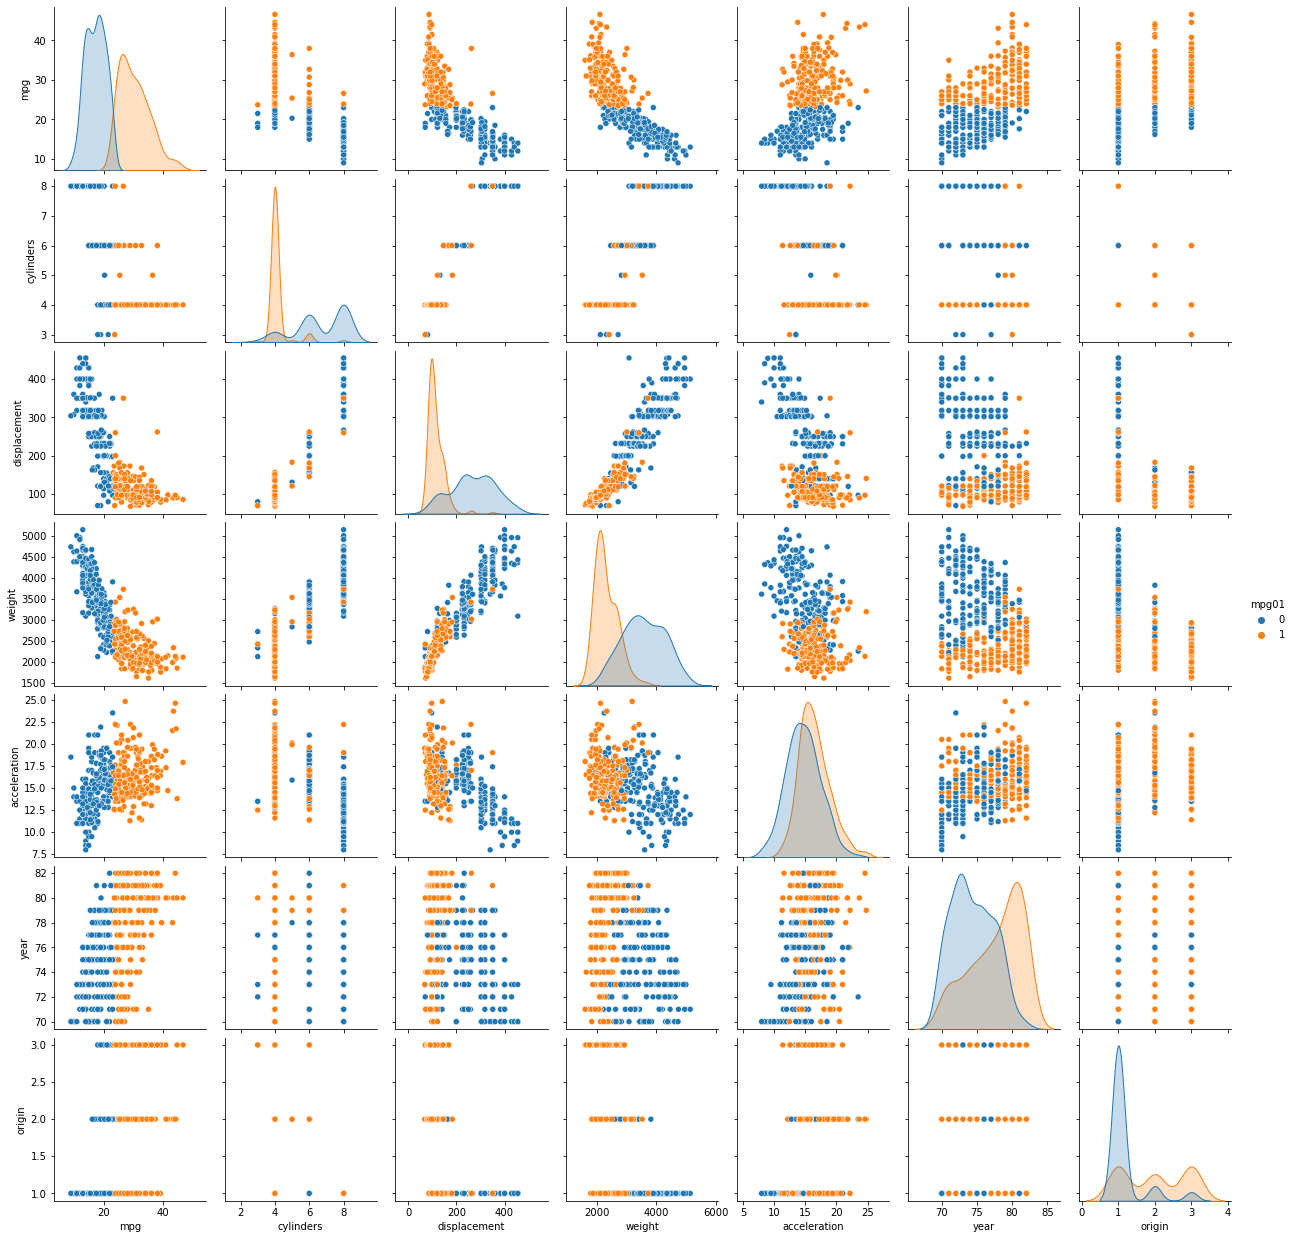

In [4]:
sns.pairplot(Auto, hue='mpg01')

<AxesSubplot:xlabel='mpg01', ylabel='weight'>

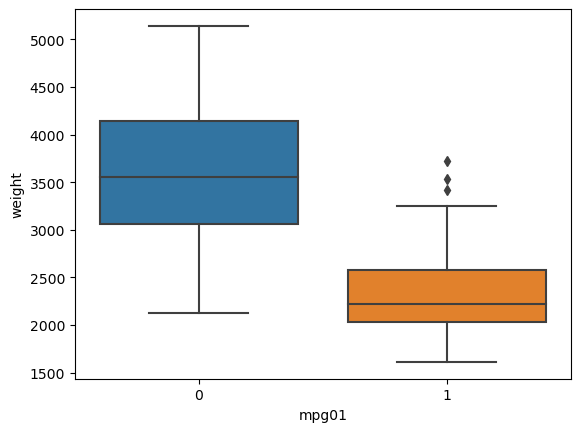

In [6]:
sns.boxplot(x='mpg01', y='weight', data=Auto)


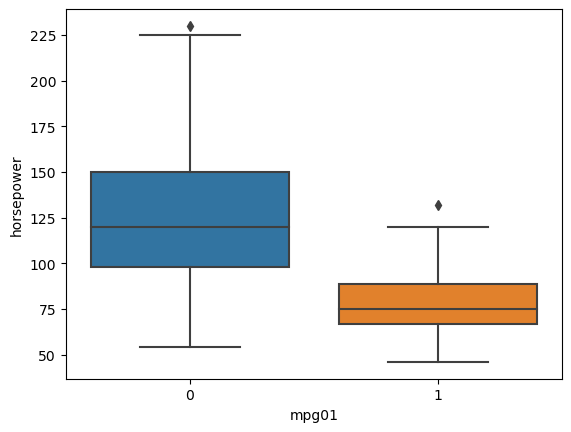

In [8]:
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna(subset=['horsepower'])
sns.boxplot(x='mpg01', y='horsepower', data=Auto)
plt.show()

- Weight: Heavier cars have lower gas mileage, so weight is likely a strong predictor of mpg01.
- Displacement: Cars with higher displacement are less fuel-efficient, making displacement another predictor.
- Cylinders: Cars with more cylinders areless fuel-efficient, so the number of cylinders may also be relevant.
- Horsepower: Cars with higher horsepower have lower gas mileage, so horsepower is relevant also.

c)

In [9]:
train_data, test_data = train_test_split(Auto, test_size=0.25)

X_train = train_data[['weight', 'horsepower', 'displacement', 'cylinders']]
y_train = train_data['mpg01']

X_test = test_data[['weight', 'horsepower', 'displacement', 'cylinders']]
y_test = test_data['mpg01']


h)

In [10]:
test_errors = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # For test error
    accuracy = accuracy_score(y_test, y_pred)
    test_error = 1 - accuracy
    test_errors.append(test_error)
    print(f'K={k}, Test Error={test_error}')

# Find the K with the lowest test error
best_k = test_errors.index(min(test_errors)) + 1
print()
print(f'Best K: {best_k}')


K=1, Test Error=0.11224489795918369
K=2, Test Error=0.10204081632653061
K=3, Test Error=0.11224489795918369
K=4, Test Error=0.09183673469387754
K=5, Test Error=0.13265306122448983
K=6, Test Error=0.12244897959183676
K=7, Test Error=0.12244897959183676
K=8, Test Error=0.12244897959183676
K=9, Test Error=0.13265306122448983
K=10, Test Error=0.11224489795918369
K=11, Test Error=0.13265306122448983
K=12, Test Error=0.12244897959183676
K=13, Test Error=0.12244897959183676
K=14, Test Error=0.11224489795918369
K=15, Test Error=0.13265306122448983
K=16, Test Error=0.11224489795918369
K=17, Test Error=0.12244897959183676
K=18, Test Error=0.11224489795918369
K=19, Test Error=0.11224489795918369
K=20, Test Error=0.11224489795918369

Best K: 4


### Q 4.8.6

a)

Probability = P = 1/(1+exp(-(𝛽0 + 𝛽1X1 + 𝛽2X2)))

So, P = 1/(1+exp(-(-6 + 0.05 * 40 + 1 * 3.5)))

P = 0.377540669

b)

For P = 0.5,

0.5 = 1/(1+exp(-(𝛽0 + 𝛽1X1 + 𝛽2X2)))

0.5 = 1/(1+exp(-(-6 + 0.05 * X1 + 1 * 3.5)))

1 = exp(6 - 0.05X1 - 3.5)

0 = 6 - 0.05X1 - 3.5

0.05X1 = 2.5

X1 = 2.5/0.05 = 50

So, the student will have to study for 50 hours.